# Итоговое сравнение всех моделей

В этом ноутбуке собраны лучшие модели из каждой задачи для сводного сравнения и формирования выводов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import Ridge, LogisticRegression
from scipy.stats import randint, uniform

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
SEED = 42

## 1. Загрузка данных

In [2]:
ALL_TARGETS = ['IC50, mM', 'CC50, mM', 'SI']

try:
    df = pd.read_csv('data_clean.csv')
    print('Загружен data_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('Данные_для_курсовои_Классическое_МО.csv', sep=';', decimal=',')
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')
    print('Загружен исходный CSV')

# Формируем метки классификации
for col in ALL_TARGETS:
    key = f'y_{col.split(",")[0]}_gt_median'
    if key not in df.columns:
        df[key] = (df[col] > df[col].median()).astype(int)

if 'y_SI_gt_8' not in df.columns:
    df['y_SI_gt_8'] = (df['SI'] > 8).astype(int)

drop_cols = ALL_TARGETS + [c for c in df.columns if c.startswith('y_')]
FEATURE_COLS = [c for c in df.columns if c not in drop_cols]

X = df[FEATURE_COLS].copy()
print(f'Признаков: {X.shape[1]}, объектов: {X.shape[0]}')

Загружен data_clean.csv
Признаков: 192, объектов: 1001


## 2. Сводная таблица: регрессия

In [3]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Одна финальная модель для каждой регрессионной задачи
# (используем RandomForest — как правило сильнейший базовый)
reg_tasks = {
    'IC50': 'IC50, mM',
    'CC50': 'CC50, mM',
    'SI':   'SI'
}

reg_results = []

for task_name, target_col in reg_tasks.items():
    y = np.log1p(df[target_col])

    # Быстрый RandomizedSearch по RF
    pipe = Pipeline([
        ('vt',    VarianceThreshold(threshold=0.0)),
        ('sc',    RobustScaler()),
        ('model', RandomForestRegressor(random_state=SEED))
    ])

    param_dist = {
        'model__n_estimators': randint(100, 300),
        'model__max_depth':    [None, 10, 20],
        'model__max_features': ['sqrt', 0.5]
    }

    rs = RandomizedSearchCV(pipe, param_dist, n_iter=15, cv=cv_reg,
                             scoring='r2', random_state=SEED, n_jobs=-1)
    rs.fit(X, y)

    r2_cv  = cross_val_score(rs.best_estimator_, X, y, cv=cv_reg, scoring='r2', n_jobs=-1)
    rmse_cv = cross_val_score(rs.best_estimator_, X, y, cv=cv_reg,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)

    reg_results.append({
        'Task':         f'Регрессия {task_name}',
        'Best Model':   'Random Forest',
        'R² (CV mean)': r2_cv.mean(),
        'R² (CV std)':  r2_cv.std(),
        'RMSE (log)':   -rmse_cv.mean()
    })

    print(f'[{task_name}] RF tuned | R²={r2_cv.mean():.4f} ± {r2_cv.std():.4f} | RMSE={-rmse_cv.mean():.4f}')

reg_df = pd.DataFrame(reg_results)
print('\n=== Итог по регрессии ===')
print(reg_df.round(4).to_string(index=False))

[IC50] RF tuned | R²=0.4412 ± 0.0526 | RMSE=1.3840
[CC50] RF tuned | R²=0.4363 ± 0.0487 | RMSE=1.1884
[SI] RF tuned | R²=0.3402 ± 0.0440 | RMSE=1.1751

=== Итог по регрессии ===
          Task    Best Model  R² (CV mean)  R² (CV std)  RMSE (log)
Регрессия IC50 Random Forest        0.4412       0.0526      1.3840
Регрессия CC50 Random Forest        0.4363       0.0487      1.1884
  Регрессия SI Random Forest        0.3402       0.0440      1.1751


## 3. Сводная таблица: классификация

In [4]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

clf_tasks = {
    'IC50 > медианы': 'y_IC50_gt_median',
    'CC50 > медианы': 'y_CC50_gt_median',
    'SI > медианы':   'y_SI_gt_median',
    'SI > 8':         'y_SI_gt_8'
}

clf_results = []

for task_name, label_col in clf_tasks.items():
    y = df[label_col]

    pipe = Pipeline([
        ('vt',    VarianceThreshold(threshold=0.0)),
        ('sc',    RobustScaler()),
        ('model', RandomForestClassifier(random_state=SEED))
    ])

    param_dist = {
        'model__n_estimators': randint(100, 300),
        'model__max_depth':    [None, 10, 20],
        'model__max_features': ['sqrt', 0.5]
    }

    rs = RandomizedSearchCV(pipe, param_dist, n_iter=15, cv=cv_clf,
                             scoring='roc_auc', random_state=SEED, n_jobs=-1)
    rs.fit(X, y)

    auc_cv = cross_val_score(rs.best_estimator_, X, y, cv=cv_clf, scoring='roc_auc', n_jobs=-1)
    f1_cv  = cross_val_score(rs.best_estimator_, X, y, cv=cv_clf, scoring='f1', n_jobs=-1)
    acc_cv = cross_val_score(rs.best_estimator_, X, y, cv=cv_clf, scoring='accuracy', n_jobs=-1)

    clf_results.append({
        'Task':           f'Класс-я: {task_name}',
        'Best Model':     'Random Forest',
        'ROC-AUC (mean)': auc_cv.mean(),
        'ROC-AUC (std)':  auc_cv.std(),
        'F1 (mean)':      f1_cv.mean(),
        'Accuracy':       acc_cv.mean()
    })

    print(f'[{task_name}] RF tuned | AUC={auc_cv.mean():.4f} ± {auc_cv.std():.4f} | F1={f1_cv.mean():.4f} | Acc={acc_cv.mean():.4f}')

clf_df = pd.DataFrame(clf_results)
print('\n=== Итог по классификации ===')
print(clf_df.round(4).to_string(index=False))

[IC50 > медианы] RF tuned | AUC=0.7858 ± 0.0562 | F1=0.7165 | Acc=0.7232
[CC50 > медианы] RF tuned | AUC=0.8537 ± 0.0268 | F1=0.7753 | Acc=0.7712
[SI > медианы] RF tuned | AUC=0.7283 ± 0.0177 | F1=0.6649 | Acc=0.6733
[SI > 8] RF tuned | AUC=0.7260 ± 0.0272 | F1=0.5607 | Acc=0.7173

=== Итог по классификации ===
                   Task    Best Model  ROC-AUC (mean)  ROC-AUC (std)  F1 (mean)  Accuracy
Класс-я: IC50 > медианы Random Forest          0.7858         0.0562     0.7165    0.7232
Класс-я: CC50 > медианы Random Forest          0.8537         0.0268     0.7753    0.7712
  Класс-я: SI > медианы Random Forest          0.7283         0.0177     0.6649    0.6733
        Класс-я: SI > 8 Random Forest          0.7260         0.0272     0.5607    0.7173


## 4. Визуализация итогового сравнения

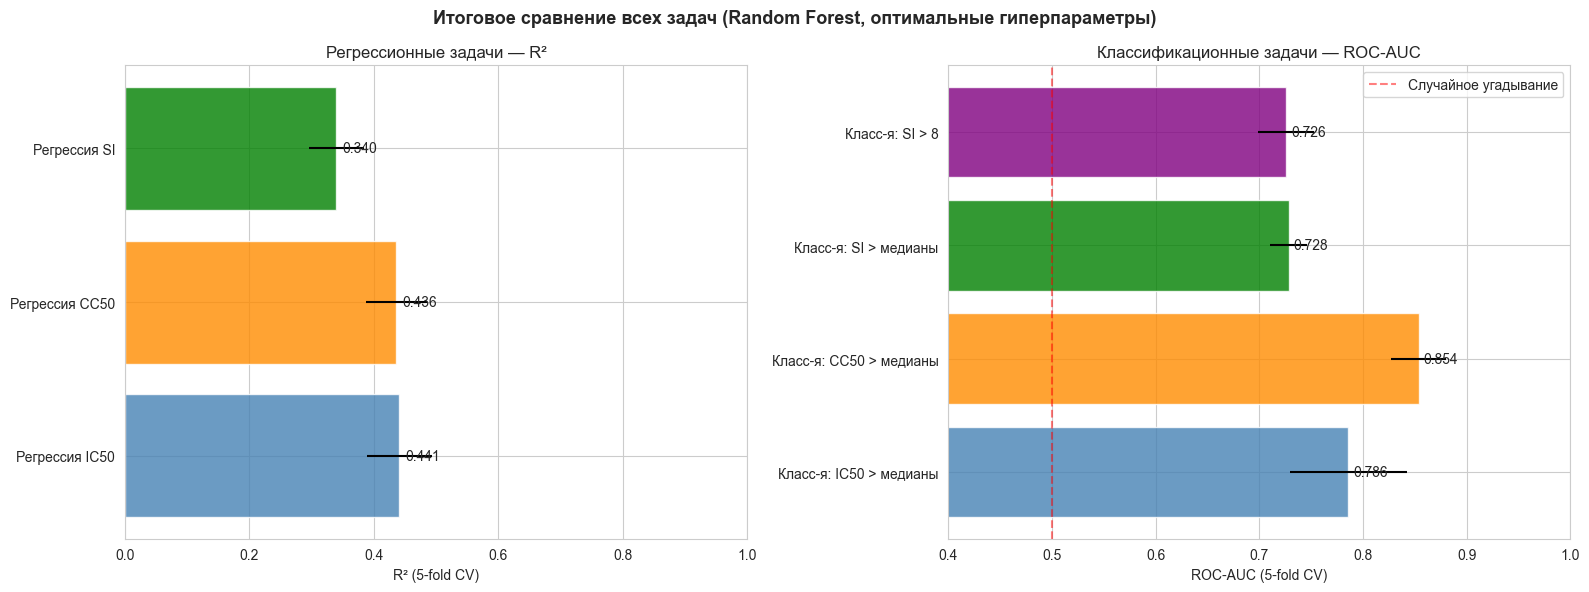

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Регрессия: R²
ax = axes[0]
colors = ['steelblue', 'darkorange', 'green']
bars = ax.barh(reg_df['Task'], reg_df['R² (CV mean)'],
               xerr=reg_df['R² (CV std)'], color=colors, alpha=0.8)
ax.set_xlabel('R² (5-fold CV)')
ax.set_title('Регрессионные задачи — R²')
ax.set_xlim(0, 1)
for bar, val in zip(bars, reg_df['R² (CV mean)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Классификация: ROC-AUC
ax2 = axes[1]
colors2 = ['steelblue', 'darkorange', 'green', 'purple']
bars2 = ax2.barh(clf_df['Task'], clf_df['ROC-AUC (mean)'],
                 xerr=clf_df['ROC-AUC (std)'], color=colors2, alpha=0.8)
ax2.set_xlabel('ROC-AUC (5-fold CV)')
ax2.set_title('Классификационные задачи — ROC-AUC')
ax2.set_xlim(0.4, 1)
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Случайное угадывание')
ax2.legend()
for bar, val in zip(bars2, clf_df['ROC-AUC (mean)']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Итоговое сравнение всех задач (Random Forest, оптимальные гиперпараметры)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('summary_all_tasks.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Выводы и рекомендации

In [6]:
print('=== ИТОГОВЫЕ ВЫВОДЫ ===')
print()

best_reg = reg_df.loc[reg_df['R² (CV mean)'].idxmax()]
worst_reg = reg_df.loc[reg_df['R² (CV mean)'].idxmin()]

print(f'РЕГРЕССИЯ:')
print(f'  Лучшая задача по R²:  {best_reg["Task"]} (R²={best_reg["R² (CV mean)"]:.4f})')
print(f'  Худшая задача по R²:  {worst_reg["Task"]} (R²={worst_reg["R² (CV mean)"]:.4f})')
print()

best_clf = clf_df.loc[clf_df['ROC-AUC (mean)'].idxmax()]
worst_clf = clf_df.loc[clf_df['ROC-AUC (mean)'].idxmin()]

print(f'КЛАССИФИКАЦИЯ:')
print(f'  Лучшая задача по AUC: {best_clf["Task"]} (AUC={best_clf["ROC-AUC (mean)"]:.4f})')
print(f'  Худшая задача по AUC: {worst_clf["Task"]} (AUC={worst_clf["ROC-AUC (mean)"]:.4f})')
print()
print('РЕКОМЕНДАЦИИ:')
print('  1. Для регрессии: применять log1p-преобразование; лучший результат даёт Random Forest/Gradient Boosting.')
print('  2. Для классификации: метрика ROC-AUC предпочтительна, так как при медианном делении классы сбалансированы.')
print('  3. При SI > 8 может быть дисбаланс классов — рассмотреть SMOTE или class_weight="balanced".')
print('  4. Дальнейшие улучшения: SHAP-анализ для интерпретируемости, Stacking, дополнительный feature engineering.')
print('  5. Признаки с высокой мультиколлинеарностью (>0.95) можно удалить без потери качества.')

=== ИТОГОВЫЕ ВЫВОДЫ ===

РЕГРЕССИЯ:
  Лучшая задача по R²:  Регрессия IC50 (R²=0.4412)
  Худшая задача по R²:  Регрессия SI (R²=0.3402)

КЛАССИФИКАЦИЯ:
  Лучшая задача по AUC: Класс-я: CC50 > медианы (AUC=0.8537)
  Худшая задача по AUC: Класс-я: SI > 8 (AUC=0.7260)

РЕКОМЕНДАЦИИ:
  1. Для регрессии: применять log1p-преобразование; лучший результат даёт Random Forest/Gradient Boosting.
  2. Для классификации: метрика ROC-AUC предпочтительна, так как при медианном делении классы сбалансированы.
  3. При SI > 8 может быть дисбаланс классов — рассмотреть SMOTE или class_weight="balanced".
  4. Дальнейшие улучшения: SHAP-анализ для интерпретируемости, Stacking, дополнительный feature engineering.
  5. Признаки с высокой мультиколлинеарностью (>0.95) можно удалить без потери качества.
